# Metropolis y Gibbs para el modelo de Ising 2D

**Pregunta:** ¿pueden Metropolis-Hastings y Gibbs reproducir correctamente el equilibrio del modelo de Ising 2D y cómo se compara su eficiencia de muestreo en distintas regiones de temperatura?

El análisis usa semillas explícitas, valida ambos métodos contra enumeración exacta y estudia una red finita sin interpretar su cambio suave como una estimación precisa del punto crítico.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from ising_mcmc import (
    effective_sample_size,
    energy_density,
    exact_statistics,
    gibbs_sweep,
    integrated_autocorrelation_time,
    magnetization_density,
    metropolis_sweep,
    random_lattice,
)

J = 1.0
h = 0.0
BETA_C = 0.5 * np.log(1.0 + np.sqrt(2.0))
print(f"Referencia del sistema infinito: beta_c = {BETA_C:.6f}")

Referencia del sistema infinito: beta_c = 0.440687


## 1. Modelo

Se considera una red cuadrada $L\times L$, con espines $s_i\in\{-1,+1\}$ y condiciones periódicas. Con $k_B=1$,

$$H(\mathbf{s})=-J\sum_{\langle i,j\rangle}s_i s_j-h\sum_i s_i,$$

donde cada enlace se cuenta una vez. Las cantidades observadas serán la energía por espín $e=H/L^2$ y la magnetización por espín $m=L^{-2}\sum_i s_i$. A campo cero se usa $|m|$ para evitar que la simetría global de inversión cancele las dos fases ordenadas.

## 2. Actualizaciones MCMC

Un sweep realiza $L^2$ selecciones aleatorias de sitio, con reemplazo.

- **Metropolis:** propone invertir el espín y acepta con $\min(1,e^{-\beta\Delta E})$.
- **Gibbs/heat bath:** vuelve a muestrear el espín con $P(s_i=+1\mid s_{-i})=[1+e^{-2\beta a_i}]^{-1}$, donde $a_i=J\sum_{j\sim i}s_j+h$.

Las implementaciones viven en src/ising_mcmc/samplers.py; aquí solo se define una rutina breve para ejecutar y medir cadenas.

In [2]:
def run_chain(sweep, beta, L, burn_in, n_samples, seed):
    rng = np.random.default_rng(seed)
    lattice = random_lattice(L, rng)

    for _ in range(burn_in):
        sweep(lattice, beta=beta, rng=rng, J=J, h=h)

    energies = np.empty(n_samples)
    abs_magnetizations = np.empty(n_samples)
    start = time.perf_counter()
    for sample in range(n_samples):
        sweep(lattice, beta=beta, rng=rng, J=J, h=h)
        energies[sample] = energy_density(lattice, J=J, h=h)
        abs_magnetizations[sample] = abs(magnetization_density(lattice))

    elapsed = time.perf_counter() - start
    return energies, abs_magnetizations, lattice.copy(), elapsed

## 3. Validación contra enumeración exacta

Para $L=4$ todavía es posible enumerar los $2^{16}$ estados. La tabla compara los promedios exactos con cadenas independientes en dos valores de $\beta$. Esta es una verificación directa de la distribución de equilibrio objetivo, no un benchmark de sistemas grandes.

In [3]:
validation_rows = []
samplers = [("Metropolis", metropolis_sweep), ("Gibbs", gibbs_sweep)]

for beta_index, beta in enumerate([0.30, 0.50]):
    exact = exact_statistics(L=4, beta=beta, J=J, h=h)
    validation_rows.append((beta, "Exacto", exact.energy_density, exact.abs_magnetization_density))
    for method_index, (name, sweep) in enumerate(samplers):
        energy, abs_m, _, _ = run_chain(
            sweep, beta, L=4, burn_in=1_000, n_samples=6_000,
            seed=100 + 10 * beta_index + method_index,
        )
        validation_rows.append((beta, name, energy.mean(), abs_m.mean()))

print(" beta  metodo          <E>/N     <|M|>/N")
print("-" * 43)
for beta, method, mean_e, mean_abs_m in validation_rows:
    print(f"{beta:5.2f}  {method:11s}  {mean_e:9.5f}  {mean_abs_m:10.5f}")

 beta  metodo          <E>/N     <|M|>/N
-------------------------------------------
 0.30  Exacto        -0.84405     0.52036
 0.30  Metropolis    -0.82921     0.51419
 0.30  Gibbs         -0.86608     0.53177
 0.50  Exacto        -1.75538     0.91894
 0.50  Metropolis    -1.77529     0.92635
 0.50  Gibbs         -1.75725     0.91804


Los dos samplers deben concordar aproximadamente con los promedios exactos; pequeñas diferencias son esperables porque las muestras consecutivas están correlacionadas y la cadena es finita.

## 4. Comportamiento al variar $\beta$

Al aumentar $\beta$ (disminuir la temperatura), aumenta el orden magnético. La línea vertical marca el valor crítico exacto del sistema infinito únicamente como referencia.

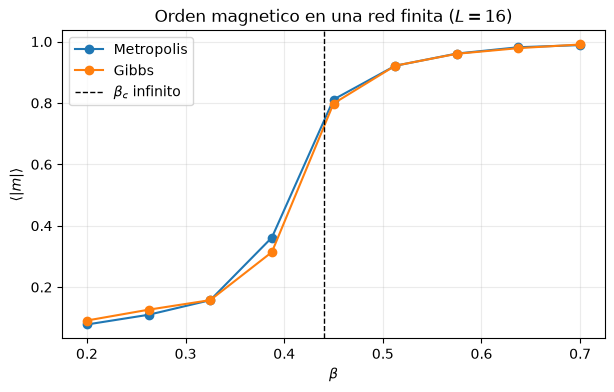

In [4]:
betas = np.linspace(0.20, 0.70, 9)
magnetization_curves = {}

for method_index, (name, sweep) in enumerate(samplers):
    means = []
    for beta_index, beta in enumerate(betas):
        near_critical = abs(beta - BETA_C) < 0.08
        burn_in = 800 if near_critical else 250
        n_samples = 1_200 if near_critical else 300
        _, abs_m, _, _ = run_chain(
            sweep, beta, L=16, burn_in=burn_in, n_samples=n_samples,
            seed=1_000 + 100 * method_index + beta_index,
        )
        means.append(abs_m.mean())
    magnetization_curves[name] = np.asarray(means)

fig, ax = plt.subplots(figsize=(7, 4))
for name, means in magnetization_curves.items():
    ax.plot(betas, means, "o-", label=name)
ax.axvline(BETA_C, color="black", linestyle="--", linewidth=1, label=r"$\beta_c$ infinito")
ax.set(xlabel=r"$\beta$", ylabel=r"$\langle |m| \rangle$", title="Orden magnetico en una red finita ($L=16$)")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

La curva es suave porque $L$ es finito. No se estima $\beta_c$ buscando la pendiente máxima: ese número dependería del ruido Monte Carlo, la malla de $\beta$, la termalización, la autocorrelación y el tamaño de la red. Una estimación rigurosa requeriría un estudio de tamaño finito que queda fuera del alcance.

## 5. Configuraciones representativas

Las configuraciones Gibbs ilustran desorden a alta temperatura, dominios cerca de la región crítica y orden a baja temperatura.

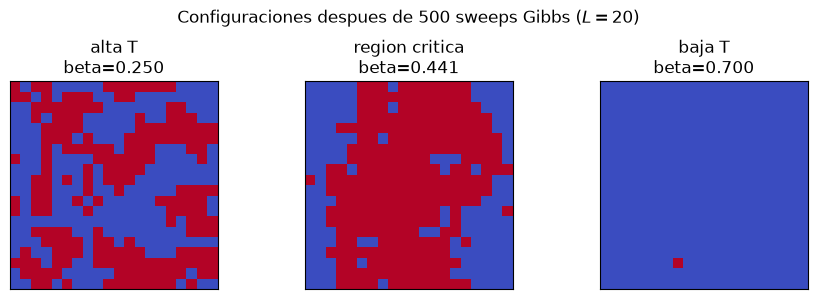

In [5]:
snapshot_betas = [0.25, BETA_C, 0.70]
snapshot_labels = ["alta T", "region critica", "baja T"]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for index, (ax, beta, label) in enumerate(zip(axes, snapshot_betas, snapshot_labels)):
    rng = np.random.default_rng(2_000 + index)
    lattice = random_lattice(20, rng)
    for _ in range(500):
        gibbs_sweep(lattice, beta=beta, rng=rng, J=J, h=h)
    ax.imshow(lattice, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"{label}\nbeta={beta:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Configuraciones despues de 500 sweeps Gibbs ($L=20$)")
fig.tight_layout()
plt.show()

## 6. Autocorrelación y eficiencia

El tiempo integrado de autocorrelación $\tau_{\mathrm{int}}$ mide cuántos sweeps hacen falta para obtener información aproximadamente nueva; el tamaño efectivo es $ESS=N/\tau_{\mathrm{int}}$. El tiempo y ESS/s se reportan por separado: estos últimos dependen de esta implementación concreta en Python y no establecen una superioridad universal.

 beta   metodo       segundos   tau_int      ESS      ESS/s
--------------------------------------------------------------
 0.250  Metropolis     1.179      3.75    186.6      158.3
 0.250  Gibbs          1.265      4.41    158.6      125.4
 0.441  Metropolis     1.227     21.89     32.0       26.1
 0.441  Gibbs          1.575     19.45     36.0       22.8
 0.700  Metropolis     1.812      2.53    276.7      152.7
 0.700  Gibbs          1.655      2.72    257.1      155.3


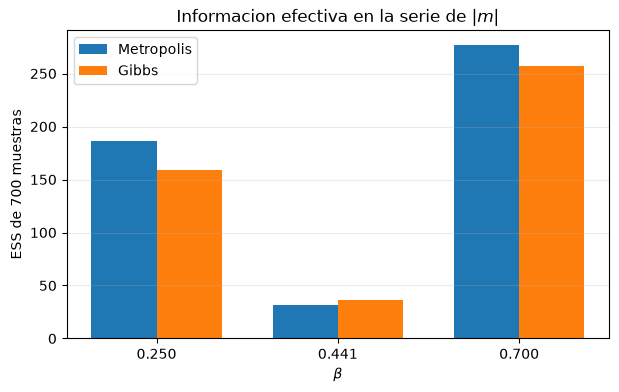

In [6]:
efficiency_rows = []
comparison_betas = [0.25, BETA_C, 0.70]

for beta_index, beta in enumerate(comparison_betas):
    for method_index, (name, sweep) in enumerate(samplers):
        _, abs_m, _, elapsed = run_chain(
            sweep, beta, L=16, burn_in=300, n_samples=700,
            seed=3_000 + 10 * beta_index + method_index,
        )
        tau = integrated_autocorrelation_time(abs_m, max_lag=150)
        ess = effective_sample_size(abs_m, max_lag=150)
        efficiency_rows.append((beta, name, elapsed, tau, ess, ess / elapsed))

print(" beta   metodo       segundos   tau_int      ESS      ESS/s")
print("-" * 62)
for beta, method, elapsed, tau, ess, ess_per_second in efficiency_rows:
    print(f"{beta:6.3f}  {method:10s}  {elapsed:8.3f}  {tau:8.2f}  {ess:7.1f}  {ess_per_second:9.1f}")

x = np.arange(len(comparison_betas))
width = 0.36
fig, ax = plt.subplots(figsize=(7, 4))
for offset, name in [(-width / 2, "Metropolis"), (width / 2, "Gibbs")]:
    ess_values = [row[4] for row in efficiency_rows if row[1] == name]
    ax.bar(x + offset, ess_values, width, label=name)
ax.set_xticks(x, [f"{beta:.3f}" for beta in comparison_betas])
ax.set(xlabel=r"$\beta$", ylabel="ESS de 700 muestras", title="Informacion efectiva en la serie de $|m|$")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()

## 7. Conclusiones y limitaciones

- Metropolis y Gibbs reproducen los promedios exactos de energía y magnetización absoluta en la red pequeña estudiada.
- Ambos muestran el cambio esperado desde configuraciones desordenadas hacia configuraciones magnetizadas al aumentar $\beta$.
- La eficiencia depende de la temperatura, del observable y de la implementación. Cerca de la región crítica, los métodos locales sufren correlaciones largas.
- Los resultados usan cadenas y redes finitas; no constituyen una determinación precisa de $\beta_c$. Tampoco se realiza escalamiento de tamaño finito ni se comparan algoritmos de clusters.